# EDA: Online Retail II

Этот ноутбук проводит полный предварительный анализ данных онлайн-ритейла, очищает транзакции и сохраняет готовые к аналитике выходные файлы

Ссылка на датасет: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci/data

In [25]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Загрузка данных и проверка структуры

Считываем CSV, приводим колонки к удобному формату и проверяем общие характеристики таблицы.


In [26]:
very_raw = pd.read_csv('../data/online_retail_II.csv', parse_dates=['InvoiceDate'])
raw = very_raw.copy()

raw = raw.rename(columns={'Price': 'UnitPrice'})

raw.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [27]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   UnitPrice    1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


## 2. Пропуски и первичная оценка качества данных

Оценим доли отсутствующих значений, проверим дубликаты.

In [28]:
raw.duplicated().sum()

np.int64(34335)

In [29]:
raw[raw.duplicated()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
657,489529,22028,PENNY FARTHING BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom
658,489529,22036,DINOSAUR BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom


Мы не можем быть уверены в ошибке сбора данных, когда видим полные дубликаты записей, т.к. ни одно из полей (или их комбинация) не обязано быть уникальным. (Время указано с точностью до минуты)

In [30]:
missing_values = raw.isna().sum()

print('Кол-во пропущенных значений:')
print(missing_values)
print('\nДоли пропущенных значений:')
print(missing_values.map(lambda x: f'{x / len(raw):.2%}'))

Кол-во пропущенных значений:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
UnitPrice           0
Customer ID    243007
Country             0
dtype: int64

Доли пропущенных значений:
Invoice         0.00%
StockCode       0.00%
Description     0.41%
Quantity        0.00%
InvoiceDate     0.00%
UnitPrice       0.00%
Customer ID    22.77%
Country         0.00%
dtype: object


Значения пропущены только в колонках Customer ID и Description. NaN в описании товара некритичен, а ID покупателя может быть пропущен для неавторизованных пользователей.

## 3. Аномалии в кодах товаров и ценах

Проверяем нестандартные значения StockCode, UnitPrice


In [31]:
# Все значения StockCode, которые не соответствуют стандартной маске 5 цифр + 0-2 буквы
stockcode_letters = raw[~raw['StockCode'].str.match(r'^\d{5}[A-Za-z]{0,2}$')]['StockCode']

unknown_codes = sorted(stockcode_letters.unique())

unknown_codes

['47503J ',
 'ADJUST',
 'ADJUST2',
 'AMAZONFEE',
 'B',
 'BANK CHARGES',
 'C2',
 'C3',
 'CRUK',
 'D',
 'DCGS0003',
 'DCGS0004',
 'DCGS0006',
 'DCGS0016',
 'DCGS0027',
 'DCGS0036',
 'DCGS0037',
 'DCGS0039',
 'DCGS0041',
 'DCGS0044',
 'DCGS0053',
 'DCGS0055',
 'DCGS0056',
 'DCGS0057',
 'DCGS0058',
 'DCGS0059',
 'DCGS0060',
 'DCGS0062',
 'DCGS0066N',
 'DCGS0066P',
 'DCGS0067',
 'DCGS0068',
 'DCGS0069',
 'DCGS0070',
 'DCGS0071',
 'DCGS0072',
 'DCGS0073',
 'DCGS0074',
 'DCGS0075',
 'DCGS0076',
 'DCGSLBOY',
 'DCGSLGIRL',
 'DCGSSBOY',
 'DCGSSGIRL',
 'DOT',
 'GIFT',
 'M',
 'PADS',
 'POST',
 'S',
 'SP1002',
 'TEST001',
 'TEST002',
 'gift_0001_10',
 'gift_0001_20',
 'gift_0001_30',
 'gift_0001_40',
 'gift_0001_50',
 'gift_0001_60',
 'gift_0001_70',
 'gift_0001_80',
 'gift_0001_90',
 'm']

In [32]:
raw[raw['StockCode'] == '47503J '].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
260886,514532,47503J,SET/3 FLORAL GARDEN TOOLS IN BAG,1,2010-07-05 10:07:00,16.13,NaN,United Kingdom


In [33]:
# В StockCode '47503J ' явно стоит лишний пробел, заменим его на правильный код
row_index = raw[raw['StockCode'] == '47503J '].index
raw.loc[row_index, 'StockCode'] = '47503J'

unknown_codes = sorted(raw[~raw['StockCode'].str.match(r'^\d{5}[A-Za-z]{0,2}$')]['StockCode'].unique())

In [34]:
# Смотрим примеры строк с неизвестными StockCode для понимания, что это может быть
for code in unknown_codes:
    display(raw[raw['StockCode'] == code].head(1))

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
70975,495732,ADJUST,Adjustment by john on 26/01/2010 16,1,2010-01-26 16:20:00,96.46,NaN,EIRE


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
249672,513564,ADJUST2,Adjustment by Peter on Jun 25 2010,1,2010-06-25 14:15:00,300.13,17050.0,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
440688,C531400,AMAZONFEE,AMAZON FEE,-1,2010-11-08 10:08:00,6706.71,NaN,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
18410,C490943,BANK CHARGES,Bank Charges,-1,2009-12-08 14:08:00,15.0,16703.0,United Kingdom


...

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
75138,496250,gift_0001_60,NaN,3,2010-01-29 16:17:00,0.0,NaN,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
75139,496251,gift_0001_70,NaN,2,2010-01-29 16:17:00,0.0,NaN,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
30620,491968,gift_0001_80,NaN,2,2009-12-14 17:56:00,0.0,NaN,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
75141,496252,gift_0001_90,NaN,2,2010-01-29 16:18:00,0.0,NaN,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
96608,498492,m,Manual,1,2010-02-19 10:56:00,2.55,NaN,United Kingdom


Все коды, которые не соответствуют маске: 5 цифр + 0-2 буквы, обозначают внутренние операции и не являются продажами (судя по описанию, имени кода и, в некоторых случаях, количеству товара и цене). Такие данные для моего анализа не нужны, поэтому избавляемся от них

In [35]:
raw = raw[raw['StockCode'].str.match(r'^\d{5}[A-Za-z]{0,2}$')]

raw.describe()

,Quantity,InvoiceDate,UnitPrice,Customer ID
count,1.061278e+06,1061278,1.061278e+06,820626.000000
mean,9.985726e+00,2011-01-02 23:20:54.602319360,3.341381e+00,15331.181611
min,-8.099500e+04,2009-12-01 07:45:00,0.000000e+00,12346.000000
25%,1.000000e+00,2010-07-09 11:44:00,1.250000e+00,13982.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15270.000000
75%,1.000000e+01,2011-07-22 12:09:00,4.130000e+00,16799.000000
max,8.099500e+04,2011-12-09 12:50:00,1.157150e+03,18287.000000
std,1.730908e+02,NaN,4.843645e+00,1694.638540


Видим что у нас есть заказы с отрицательным кол-вом товара и заказы с нулевой ценой.

In [36]:
issues = {
    'Отрицательное quantity': int((raw['Quantity'] < 0).sum()),
    'Нулевое quantity': int((raw['Quantity'] == 0).sum()),
    'Отрицательный price': int((raw['UnitPrice'] < 0).sum()),
    'Нулевой price': int((raw['UnitPrice'] == 0).sum()),
    'Нет Customer ID': int(raw['Customer ID'].isna().sum()),
}

issues

{'Отрицательное quantity': 21711,
 'Нулевое quantity': 0,
 'Отрицательный price': 0,
 'Нулевой price': 6116,
 'Нет Customer ID': 240652}

In [37]:
returns = raw[raw['Invoice'].str.startswith('C')]

print(f"Максимальное quantity в возвратах: {returns['Quantity'].max()}")
print(f"Минимальный price в возвратах: {returns['UnitPrice'].min()}")

print(f"Кол-во возвратов: {returns.shape[0]}")

Максимальное quantity в возвратах: -1
Минимальный price в возвратах: 0.03
Кол-во возвратов: 18285


- Все отмены заказов записаны с отрицательным кол-вом товаров и с ненулевой положительной ценой.

- Но возвраты не объясняют все отрицательные Quantity

- Также они не объясняют нулевую цену

Разберемся, что скрывается за записями, которые не попадают в категорию нормальных продаж или официальных отмен

In [38]:
# Записи с нулевой ценой
zero_price = raw[raw['UnitPrice'] == 0]
print(f"Записей с нулевой ценой: {len(zero_price)}")

print(f"Из них доля записей, привязаных к Customer ID: {zero_price['Customer ID'].notna().sum() / len(zero_price):.2%}")

zero_price['Description'].value_counts().head(15)

Записей с нулевой ценой: 6116
Из них доля записей, привязаных к Customer ID: 1.00%


Description
check                            162
?                                 92
damages                           84
damaged                           81
found                             28
missing                           27
sold as set on dotcom             20
Damaged                           17
adjustment                        16
OWL DOORSTOP                      15
POLYESTER FILLER PAD 45x45cm      12
dotcom                            12
amazon                            11
IVORY KITCHEN SCALES              10
FRENCH BLUE METAL DOOR SIGN 1     10
Name: count, dtype: int64

Нулевая цена: таких записей немного относительно всего датасета, и только малая часть из них имеет Customer ID. В остальных случаях в описании значатся damages, missing, check, ?. Это технические списания, а не продажи. То есть записи с ID клиента выглядят как реальное взаимодействие с клиентом, но их доля ничтожна

In [39]:
# Отрицательное Quantity, которое НЕ является официальной отменой
neg_no_c = raw[(raw['Quantity'] < 0) & (~raw['Invoice'].str.match(r'^[C]'))]
print(f"Отрицательное кол-во без пометки 'C' (не возвраты): {len(neg_no_c)}")

display(neg_no_c['Description'].value_counts().head(15))

neg_no_c.head(10)

Отрицательное кол-во без пометки 'C' (не возвраты): 3426


Description
check                     123
damages                    84
?                          83
damaged                    78
missing                    27
sold as set on dotcom      20
Damaged                    17
thrown away                 9
smashed                     9
Unsaleable, destroyed.      9
dotcom                      8
??                          7
damages?                    7
given away                  6
crushed                     6
Name: count, dtype: int64

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom


In [40]:
print(f"Доля транзакций с ценой 0: {len(neg_no_c[neg_no_c['UnitPrice'] == 0]) / len(neg_no_c):.2%}")

print(f"Доля транзакций с пропущенным ID покупателя: {neg_no_c['Customer ID'].isna().sum() / len(neg_no_c):.2%}")

Доля транзакций с ценой 0: 100.00%
Доля транзакций с пропущенным ID покупателя: 100.00%


Отрицательное количество без 'C' в StockCode: Все 3426 такие записи имеют цену 0 и пропущенный Customer ID. Описания вроде lost, short, damages, smashed окончательно доказывают, что это инвентаризационные корректировки

## 4. Финальная очистка данных

Сохранение чистой версии датасета только с продажами и возвратами клиентов

### Как в этих данных понимать заказ

В датасете одна строка это не заказ, а товарная позиция внутри заказа. Поэтому сущность заказа можно восстановить по Invoice: один Invoice = один чек, а строки с разными StockCode - товары внутри этого чека.

In [41]:
# Убираем записи с нулевой ценой (технические списания/ошибки)
clean_data = raw[raw['UnitPrice'] > 0].copy()

# Убираем отрицательные количества, которые НЕ являются возвратами
clean_data = clean_data[~((clean_data['Quantity'] < 0) & (~clean_data['Invoice'].str.startswith('C')))]

# Проверка результата
print(f"Размер исходного датасета: {len(very_raw)}")
print(f"Размер очищенного датасета: {len(clean_data)}")
print(f"Удалено записей: {len(very_raw) - len(clean_data)}")

Размер исходного датасета: 1067371
Размер очищенного датасета: 1055162
Удалено записей: 12209


In [42]:
# Создаем новые признаки для удобства анализа
clean_data['InvoiceDateOnly'] = clean_data['InvoiceDate'].dt.date
clean_data['InvoiceMonth'] = clean_data['InvoiceDate'].dt.to_period('M')
clean_data['InvoiceYear'] = clean_data['InvoiceDate'].dt.year

clean_data['is_return'] = clean_data['Invoice'].str.startswith('C')
clean_data['is_sale'] = ~clean_data['is_return']

clean_data['CheckoutPrice'] = clean_data['Quantity'] * clean_data['UnitPrice']
clean_data['SalesAmount'] = clean_data['CheckoutPrice'].where(clean_data['is_sale'], 0)
clean_data['RefundAmount'] = clean_data['CheckoutPrice'].abs().where(clean_data['is_return'], 0)
clean_data['NetAmount'] = clean_data['SalesAmount'] - clean_data['RefundAmount']

In [43]:
clean_data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country,InvoiceDateOnly,InvoiceMonth,InvoiceYear,is_return,is_sale,CheckoutPrice,SalesAmount,RefundAmount,NetAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12-01,2009-12,2009,False,True,83.4,83.4,0.0,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009-12,2009,False,True,81.0,81.0,0.0,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009-12,2009,False,True,81.0,81.0,0.0,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12-01,2009-12,2009,False,True,100.8,100.8,0.0,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12-01,2009-12,2009,False,True,30.0,30.0,0.0,30.0


In [44]:
clean_data.describe()

,Quantity,InvoiceDate,UnitPrice,Customer ID,InvoiceYear,CheckoutPrice,SalesAmount,RefundAmount,NetAmount
count,1.055162e+06,1055162,1.055162e+06,820565.000000,1.055162e+06,1.055162e+06,1.055162e+06,1.055162e+06,1.055162e+06
mean,1.034959e+01,2011-01-03 08:20:15.828697088,3.360749e+00,15331.267746,2.010426e+03,1.836919e+01,1.905773e+01,6.885382e-01,1.836919e+01
min,-8.099500e+04,2009-12-01 07:45:00,3.000000e-02,12346.000000,2.009000e+03,-1.684696e+05,0.000000e+00,0.000000e+00,-1.684696e+05
25%,1.000000e+00,2010-07-11 11:35:00,1.250000e+00,13982.000000,2.010000e+03,3.750000e+00,3.750000e+00,0.000000e+00,3.750000e+00
50%,3.000000e+00,2010-12-07 15:31:00,2.100000e+00,15270.000000,2.010000e+03,9.900000e+00,9.900000e+00,0.000000e+00,9.900000e+00
75%,1.000000e+01,2011-07-24 10:37:00,4.130000e+00,16799.000000,2.011000e+03,1.770000e+01,1.770000e+01,0.000000e+00,1.770000e+01
max,8.099500e+04,2011-12-09 12:50:00,1.157150e+03,18287.000000,2.011000e+03,1.684696e+05,1.684696e+05,1.684696e+05,1.684696e+05
std,1.667040e+02,NaN,4.850958e+00,1694.610929,5.739577e-01,2.664597e+02,1.953398e+02,1.811543e+02,2.664597e+02


In [45]:
clean_data.to_csv('../data/clean_online_retail_II.csv', index=False)

## 5. Первичная визуализация

Графики распределения признаков

### Распределение выручки по странам/категориям

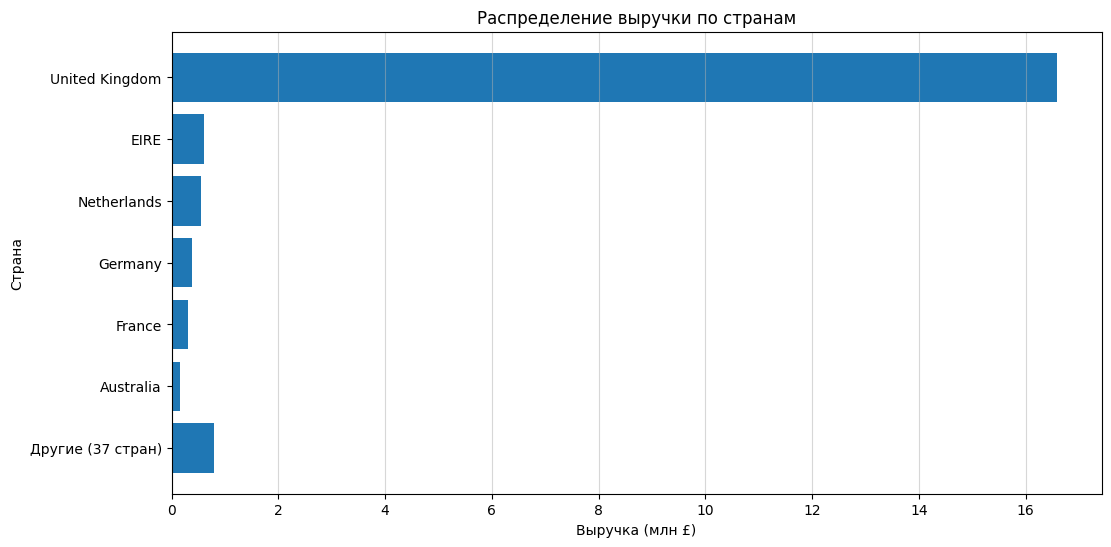

In [46]:
import matplotlib.pyplot as plt


country_revenue = clean_data.groupby('Country').sum('CheckoutPrice')['CheckoutPrice'].sort_values(ascending=False)
country_revenue = country_revenue / 1e6
top_countries = country_revenue.head(6)
other_revenue = country_revenue.iloc[6:].sum()
top_countries[f'Другие ({len(country_revenue) - 6} стран)'] = other_revenue
top_countries = top_countries.iloc[::-1]

plt.figure(figsize=(12, 6))

plt.barh(top_countries.index, top_countries.values)
plt.xlabel('Выручка (млн £)')
plt.ylabel('Страна')
plt.title('Распределение выручки по странам')
plt.grid(axis='x', alpha=0.5)

### Активность по месяцам

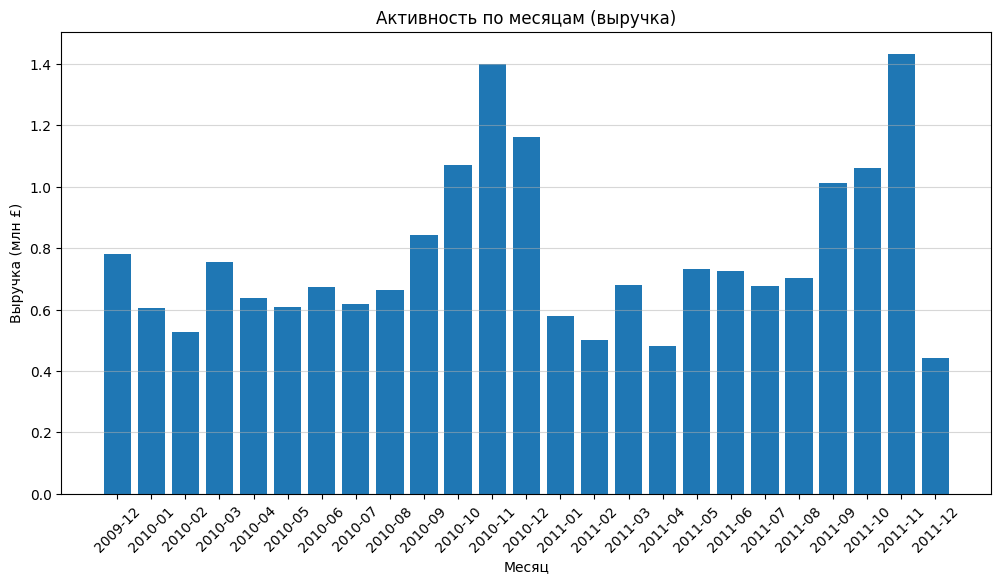

In [47]:
monthly_revenue = clean_data.groupby(clean_data['InvoiceDate'].dt.to_period('M'))['CheckoutPrice'].sum() / 1e6

plt.figure(figsize=(12, 6))

plt.bar(monthly_revenue.index.astype(str), monthly_revenue.values)
plt.xlabel('Месяц')
plt.ylabel('Выручка (млн £)')
plt.title('Активность по месяцам (выручка)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)

### Топ товаров по выручке

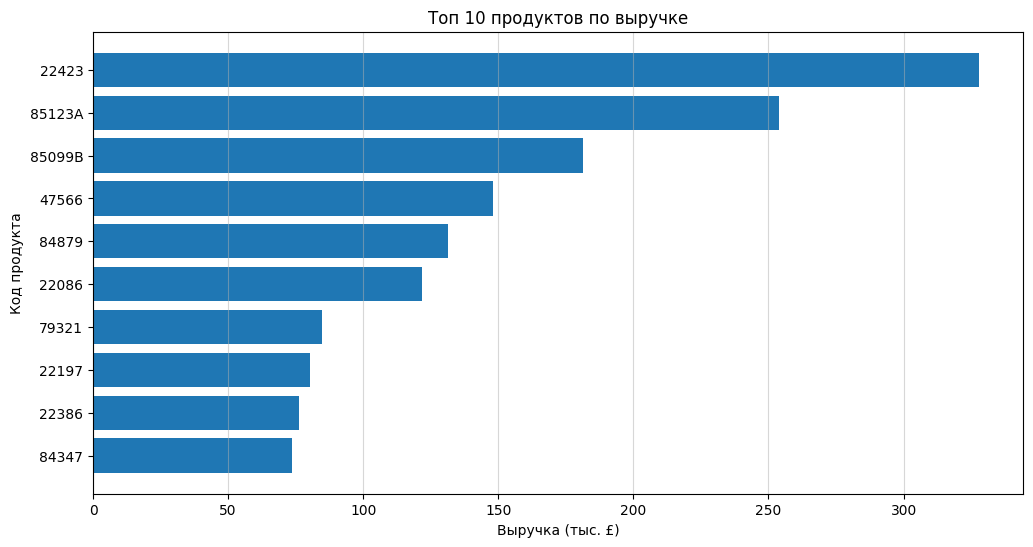

In [48]:
product_revenue = clean_data.groupby('StockCode').sum('CheckoutPrice')['CheckoutPrice'].sort_values()
product_revenue = product_revenue / 1e3
top_products = product_revenue.tail(10)

plt.figure(figsize=(12, 6))

plt.barh(top_products.index, top_products.values)
plt.xlabel('Выручка (тыс. £)')
plt.ylabel('Код продукта')
plt.title('Топ 10 продуктов по выручке')
plt.grid(axis='x', alpha=0.5)